## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle
import gc

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../Modules")
sys.path.insert(0, "../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000002168A8A3AD0> [0]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'

In [4]:
years = range(2024, 2025)

In [5]:
timelines = []

for year in years:
    df = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_{year}_filled_mean_rain_shp.csv', encoding=enc)
    print(f'Year: {year} | {df.shape}')
    timelines.append(df)

Year: 2024 | (134871, 44)


In [6]:
# timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_2016-2018_filled.csv', encoding=enc)
# wnv_file = pd.read_csv(f'../../data/{NUTS0}_WNV_cases_GRID_2010-2021.csv', encoding=enc)

timeline_file = pd.concat(timelines, ignore_index=True, axis = 0)

In [7]:
del df
del timelines

gc.collect()

270

In [8]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,22.925360,36.229230,0,2024-01-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,14423.000000,14293.000000,3.054760,1,14282.000000,14125.709677,14316.551724,14129.206897,14460.645161,14136.870968,14731.566667,14301.666667,3.054760,3.054760,3.054760,3.054760,2.000000,1,1
1,22.925360,36.229230,0,2024-01-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,14423.000000,14293.000000,0.941434,2,14282.000000,14125.709677,14316.551724,14129.206897,14460.645161,14136.870968,14731.566667,14301.666667,3.996194,3.996194,3.996194,3.996194,2.000000,1,1
2,22.925360,36.229230,0,2024-01-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,14423.000000,14293.000000,0.504189,3,14282.000000,14125.709677,14316.551724,14129.206897,14460.645161,14136.870968,14731.566667,14301.666667,4.500383,4.500383,4.500383,4.500383,2.000000,1,1
3,22.925360,36.229230,0,2024-01-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,14423.000000,14306.000000,2.075784,4,14282.000000,14125.709677,14316.551724,14129.206897,14460.645161,14136.870968,14731.566667,14301.666667,6.576167,6.576167,6.576167,6.576167,2.000000,1,1
4,22.925360,36.229230,0,2024-01-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2024,1,0.455092,0.169199,-0.358748,-0.169199,0.392609,0.202817,-0.266726,-0.202817,0.065993,0.073509,0.117318,0.073509,14455.000000,14306.000000,0.334416,5,14282.000000,14125.709677,14316.551724,14129.206897,14460.645161,14136.870968,14731.566667,14301.666667,6.910583,6.910583,6.910583,6.910583,2.000000,1,1


In [9]:
timeline_file.shape

(134871, 44)

In [10]:
# wnv_file.head()

In [11]:
# wnv_file.shape

In [12]:
try:
    timeline_file.drop(columns=['Unnamed: 0'], inplace=True)
except KeyError:
    print ("column not found")

column not found


In [13]:
temprature_cols = timeline_file.filter(regex='^lst_*').columns.tolist()

timeline_file[temprature_cols] = timeline_file[temprature_cols].apply(lambda x : x * 0.02 - 273.15)

In [14]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,22.925360,36.229230,0,2024-01-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,15.310000,12.710000,3.054760,1,12.490000,9.364194,13.181034,9.434138,16.062903,9.587419,21.481333,12.883333,3.054760,3.054760,3.054760,3.054760,2.000000,1,1
1,22.925360,36.229230,0,2024-01-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,15.310000,12.710000,0.941434,2,12.490000,9.364194,13.181034,9.434138,16.062903,9.587419,21.481333,12.883333,3.996194,3.996194,3.996194,3.996194,2.000000,1,1
2,22.925360,36.229230,0,2024-01-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,15.310000,12.710000,0.504189,3,12.490000,9.364194,13.181034,9.434138,16.062903,9.587419,21.481333,12.883333,4.500383,4.500383,4.500383,4.500383,2.000000,1,1
3,22.925360,36.229230,0,2024-01-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,15.310000,12.970000,2.075784,4,12.490000,9.364194,13.181034,9.434138,16.062903,9.587419,21.481333,12.883333,6.576167,6.576167,6.576167,6.576167,2.000000,1,1
4,22.925360,36.229230,0,2024-01-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2024,1,0.455092,0.169199,-0.358748,-0.169199,0.392609,0.202817,-0.266726,-0.202817,0.065993,0.073509,0.117318,0.073509,15.950000,12.970000,0.334416,5,12.490000,9.364194,13.181034,9.434138,16.062903,9.587419,21.481333,12.883333,6.910583,6.910583,6.910583,6.910583,2.000000,1,1


In [15]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [16]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)

timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [17]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [18]:
timeline_file

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,month_sin,month_cos
0,22.925360,36.229230,0,2024-01-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,15.310000,12.710000,3.054760,1,12.490000,9.364194,13.181034,9.434138,16.062903,9.587419,21.481333,12.883333,3.054760,3.054760,3.054760,3.054760,2.000000,1,1,14.010000,10.927097,11.307586,12.825161,17.182333,0.500000,0.866025
1,22.925360,36.229230,0,2024-01-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,15.310000,12.710000,0.941434,2,12.490000,9.364194,13.181034,9.434138,16.062903,9.587419,21.481333,12.883333,3.996194,3.996194,3.996194,3.996194,2.000000,1,1,14.010000,10.927097,11.307586,12.825161,17.182333,0.500000,0.866025
2,22.925360,36.229230,0,2024-01-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,15.310000,12.710000,0.504189,3,12.490000,9.364194,13.181034,9.434138,16.062903,9.587419,21.481333,12.883333,4.500383,4.500383,4.500383,4.500383,2.000000,1,1,14.010000,10.927097,11.307586,12.825161,17.182333,0.500000,0.866025
3,22.925360,36.229230,0,2024-01-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,15.310000,12.970000,2.075784,4,12.490000,9.364194,13.181034,9.434138,16.062903,9.587419,21.481333,12.883333,6.576167,6.576167,6.576167,6.576167,2.000000,1,1,14.140000,10.927097,11.307586,12.825161,17.182333,0.500000,0.866025
4,22.925360,36.229230,0,2024-01-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2024,1,0.455092,0.169199,-0.358748,-0.169199,0.392609,0.202817,-0.266726,-0.202817,0.065993,0.073509,0.117318,0.073509,15.950000,12.970000,0.334416,5,12.490000,9.364194,13.181034,9.434138,16.062903,9.587419,21.481333,12.883333,6.910583,6.910583,6.910583,6.910583,2.000000,1,1,14.460000,10.927097,11.307586,12.825161,17.182333,0.500000,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134866,24.055470,37.792330,736,2024-06-27,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,2024,6,0.179128,-0.058272,-0.261784,0.058272,0.195413,-0.062499,-0.272704,0.062499,0.042326,0.027019,0.025970,0.027019,34.710000,21.390000,NaN,27,13.570000,7.338387,14.532759,7.617586,17.823548,9.617097,26.171333,14.402667,0.000000,0.000000,0.000000,469.335259,2.000000,1,1,28.050000,10.454194,11.075172,13.720323,20.287000,0.000000,-1.000000
134867,24.055470,37.792330,736,2024-06-28,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,2024,6,0.169526,-0.077491,-0.256582,0.077491,0.184873,-0.080838,-0.266722,0.080838,0.039011,0.027418,0.022209,0.027418,37.390000,23.910000,NaN,28,13.570000,7.338387,14.532759,7.617586,17.823548,9.617097,26.171333,14.402667,0.000000,0.000000,0.000000,469.335259,2.000000,1,1,30.650000,10.454194,11.075172,13.720323,20.287000,0.000000,-1.000000
134868,24.055470,37.792330,736,2024-06-29,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,2024,6,0.169526,-0.077491,-0.256582,0.077491,0.184873,-0.080838,-0.26672

In [19]:
timeline_file.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
timeline_file['date_string'] = timeline_file['month'].astype(str) + '-' + timeline_file['year'].astype(str)
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['date_string'], format='%m-%Y').dt.to_period('M')
timeline_file.drop(columns=['date_string'], inplace = True)

In [20]:
gc.collect()

0

In [21]:
grouped_by_month = timeline_file.drop(columns=['dt_placement_daily']).groupby(['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME'], as_index = False)

grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

In [22]:
del timeline_file
gc.collect()

0

In [23]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mean[['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME','x','y','MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_min[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_min', 'lst_night': 'lst_night_min'}),
                                     grouped_by_month_max[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_max', 'lst_night': 'lst_night_max'}),
                                     grouped_by_month_sum[['rainfall']].rename(columns={'rainfall':'rainfall_acc'})], axis=1)

In [24]:
del grouped_by_month
del grouped_by_month_mean
del grouped_by_month_min
del grouped_by_month_max
del grouped_by_month_sum
del grouped_by_month_last

gc.collect()

0

In [25]:
grouped_by_month_dataset.head()

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2024-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2024.000000,1.000000,0.453702,0.162273,-0.373644,-0.162273,0.417976,0.173836,-0.328185,-0.173836,0.044335,0.044013,0.054985,0.044013,12.490000,9.364194,10.927097,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,4.883174,10.569020,14.188456,148.323639,151.378399,7.390000,-1.450000,16.550000,12.970000,151.378399
1,0,2024-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2024.000000,2.000000,0.459899,0.156819,-0.383792,-0.156819,0.433261,0.163800,-0.360059,-0.163800,0.059659,0.041815,0.063084,0.041815,13.181034,9.434138,11.307586,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,7.137716,114.943450,195.384068,207.398673,358.372156,9.510000,4.910000,15.910000,11.550000,206.993757
2,0,2024-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2024.000000,3.000000,0.476548,0.151681,-0.419050,-0.151681,0.461091,0.144800,-0.410378,-0.144800,0.034096,0.020828,0.027412,0.020828,16.062903,9.587419,12.825161,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,0.941541,4.710541,9.336516,13.069732,387.559926,11.890000,5.270000,24.190000,13.750000,29.187771
3,0,2024-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2024.000000,4.000000,0.456022,0.120288,-0.422576,-0.120288,0.428696,0.110163,-0.399211,-0.110163,0.042036,0.025916,0.026007,0.025916,21.481333,12.883333,17.182333,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,1.022162,0.302366,28.825284,30.664851,418.224778,13.990000,6.830000,28.130000,16.290000,30.664851
4,0,2024-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2024.000000,5.000000,0.413255,0.098957,-0.399515,-0.098957,0.386260,0.080748,-0.379315,-0.080748,0.043332,0.030739,0.026155,0.030739,25.675000,14.563571,20.119286,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,0.267375,0.329880,3.180171,8.288634,426.513412,16.570000,12.130000,30.550000,17.990000,8.288634


In [26]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2024-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2024.000000,1.000000,0.453702,0.162273,-0.373644,-0.162273,0.417976,0.173836,-0.328185,-0.173836,0.044335,0.044013,0.054985,0.044013,12.490000,9.364194,10.927097,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,4.883174,10.569020,14.188456,148.323639,151.378399,7.390000,-1.450000,16.550000,12.970000,151.378399
1,0,2024-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2024.000000,2.000000,0.459899,0.156819,-0.383792,-0.156819,0.433261,0.163800,-0.360059,-0.163800,0.059659,0.041815,0.063084,0.041815,13.181034,9.434138,11.307586,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,7.137716,114.943450,195.384068,207.398673,358.372156,9.510000,4.910000,15.910000,11.550000,206.993757
2,0,2024-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2024.000000,3.000000,0.476548,0.151681,-0.419050,-0.151681,0.461091,0.144800,-0.410378,-0.144800,0.034096,0.020828,0.027412,0.020828,16.062903,9.587419,12.825161,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,0.941541,4.710541,9.336516,13.069732,387.559926,11.890000,5.270000,24.190000,13.750000,29.187771
3,0,2024-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2024.000000,4.000000,0.456022,0.120288,-0.422576,-0.120288,0.428696,0.110163,-0.399211,-0.110163,0.042036,0.025916,0.026007,0.025916,21.481333,12.883333,17.182333,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,1.022162,0.302366,28.825284,30.664851,418.224778,13.990000,6.830000,28.130000,16.290000,30.664851
4,0,2024-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2024.000000,5.000000,0.413255,0.098957,-0.399515,-0.098957,0.386260,0.080748,-0.379315,-0.080748,0.043332,0.030739,0.026155,0.030739,25.675000,14.563571,20.119286,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,0.267375,0.329880,3.180171,8.288634,426.513412,16.570000,12.130000,30.550000,17.990000,8.288634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5154,736,2024-03,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,24.055470,37.792330,2.000000,1.000000,1.000000,2024.000000,3.000000,0.337806,0.067057,-0.338498,-0.067057,0.320229,0.119285,-0.285968,-0.119285,0.029700,0.020539,0.020131,0.020539,17.823548,9.617097,13.720323,13.570000,14.532759,17.823548,26.171333,7.338387,7.617586,9.617097,14.402667,10.454194,11.075172,13.720323,20.287000,3.696709,4.727735,26.081495,40.722064,351.171187,7.470000,4.870000,26.930000,13.090000,114.597964
5155,736,2024-04,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,24.055470,37.792330,2.000000,1.000000,1.000000,2024.000000,4.000000,0.287161,0.019035,-0.323382,-0.019035,0.328067,0.042632,

In [27]:
grouped_by_month_dataset['lst_min'] = grouped_by_month_dataset.apply(lambda row: min(row['lst_day_min'], row['lst_night_min']), axis=1)
grouped_by_month_dataset['lst_max'] = grouped_by_month_dataset.apply(lambda row: max(row['lst_day_max'], row['lst_night_max']), axis=1)

In [28]:
grouped_by_month_dataset.drop(columns=['lst_day_min', 'lst_night_min', 'lst_day_max', 'lst_night_max'], inplace=True)

In [29]:
grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']] = grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']].astype(int)


In [30]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max
0,0,2024-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,1,0.453702,0.162273,-0.373644,-0.162273,0.417976,0.173836,-0.328185,-0.173836,0.044335,0.044013,0.054985,0.044013,12.490000,9.364194,10.927097,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,4.883174,10.569020,14.188456,148.323639,151.378399,151.378399,-1.450000,16.550000
1,0,2024-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,2,0.459899,0.156819,-0.383792,-0.156819,0.433261,0.163800,-0.360059,-0.163800,0.059659,0.041815,0.063084,0.041815,13.181034,9.434138,11.307586,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,7.137716,114.943450,195.384068,207.398673,358.372156,206.993757,4.910000,15.910000
2,0,2024-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,3,0.476548,0.151681,-0.419050,-0.151681,0.461091,0.144800,-0.410378,-0.144800,0.034096,0.020828,0.027412,0.020828,16.062903,9.587419,12.825161,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,0.941541,4.710541,9.336516,13.069732,387.559926,29.187771,5.270000,24.190000
3,0,2024-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,4,0.456022,0.120288,-0.422576,-0.120288,0.428696,0.110163,-0.399211,-0.110163,0.042036,0.025916,0.026007,0.025916,21.481333,12.883333,17.182333,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,1.022162,0.302366,28.825284,30.664851,418.224778,30.664851,6.830000,28.130000
4,0,2024-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,5,0.413255,0.098957,-0.399515,-0.098957,0.386260,0.080748,-0.379315,-0.080748,0.043332,0.030739,0.026155,0.030739,25.675000,14.563571,20.119286,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,0.267375,0.329880,3.180171,8.288634,426.513412,8.288634,12.130000,30.550000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5154,736,2024-03,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,24.055470,37.792330,2,1,1,2024,3,0.337806,0.067057,-0.338498,-0.067057,0.320229,0.119285,-0.285968,-0.119285,0.029700,0.020539,0.020131,0.020539,17.823548,9.617097,13.720323,13.570000,14.532759,17.823548,26.171333,7.338387,7.617586,9.617097,14.402667,10.454194,11.075172,13.720323,20.287000,3.696709,4.727735,26.081495,40.722064,351.171187,114.597964,4.870000,26.930000
5155,736,2024-04,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,24.055470,37.792330,2,1,1,2024,4,0.287161,0.019035,-0.323382,-0.019035,0.328067,0.042632,-0.344499,-0.042632,0.049040,0.032059,0.028866,0.032059,26.171333,14.402667,20.287000,13.570000,14.532759,17.823548,26.171333,7.338387,7.617586,9.617097,14.402667,10.454194,11.075172,13.720323,20.287000,1.305721,13.087455,20.658826,39.171640,390.342828,39.171640,11.850000,31.930000
5156,736,2024-05,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,24.055470,37.792330,2,1,1,2024,5,0.217483,-0.034

### Add Geomorphological and Land Cover/Use

In [31]:
dataset_locations = grouped_by_month_dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [32]:
dataset_locations_per_year = grouped_by_month_dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [33]:
dataset_locations

,x,y
0,22.925360,36.229230
1,22.925360,36.319060
2,22.925360,36.319060
3,22.925360,36.337030
4,22.947520,36.193290
...,...,...
968,24.055470,37.756400
969,24.055470,37.774360
970,24.055470,37.774360
971,24.055470,37.774360


In [34]:
dataset_locations_per_year

,x,y,year
0,22.925360,36.229230,2024
1,22.925360,36.319060,2024
2,22.925360,36.319060,2024
3,22.925360,36.337030,2024
4,22.947520,36.193290,2024
...,...,...,...
968,24.055470,37.756400,2024
969,24.055470,37.774360,2024
970,24.055470,37.774360,2024
971,24.055470,37.774360,2024


In [35]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [36]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 2.183223232975093e-06
Max distance: 0.0004080402541026767


In [37]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

C:\Users\dimit\AppData\Local\Temp\ipykernel_14828\180837051.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)


In [38]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.925360,36.229230,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166
1,22.925360,36.319060,1765.480985,6926.111027,10,197.077012,274.126271,180.773995,0.000000,5.117582
2,22.925360,36.319060,1765.480985,6926.111027,10,197.077012,274.126271,180.773995,0.000000,5.117582
3,22.925360,36.337030,1903.382813,7495.847864,7,235.289966,337.325945,186.904082,0.000000,1.487290
4,22.947520,36.193290,2106.538145,3337.921859,15,286.834685,337.529195,188.715719,0.000000,1.065844
...,...,...,...,...,...,...,...,...,...,...
968,24.055470,37.756400,1553.065873,64.026233,2,188.035865,71.551740,174.154998,0.000000,217.731245
969,24.055470,37.774360,2045.112663,134.017517,28,278.377388,82.546453,182.070048,0.000000,83.284376
970,24.055470,37.774360,2045.112663,134.017517,28,278.377388,82.546453,182.070048,0.000000,83.284376
971,24.055470,37.774360,2045.112663,134.017517,28,278.377388,82.546453,182.070048,0.000000,83.284376


In [39]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [40]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [41]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [42]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.925360,36.229230,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166
1,22.925360,36.319060,1765.480985,6926.111027,10,197.077012,274.126271,180.773995,0.000000,5.117582
2,22.925360,36.319060,1765.480985,6926.111027,10,197.077012,274.126271,180.773995,0.000000,5.117582
3,22.925360,36.337030,1903.382813,7495.847864,7,235.289966,337.325945,186.904082,0.000000,1.487290
4,22.947520,36.193290,2106.538145,3337.921859,15,286.834685,337.529195,188.715719,0.000000,1.065844
...,...,...,...,...,...,...,...,...,...,...
968,24.055470,37.756400,1553.065873,64.026233,2,188.035865,71.551740,174.154998,0.000000,217.731245
969,24.055470,37.774360,2045.112663,134.017517,28,278.377388,82.546453,182.070048,0.000000,83.284376
970,24.055470,37.774360,2045.112663,134.017517,28,278.377388,82.546453,182.070048,0.000000,83.284376
971,24.055470,37.774360,2045.112663,134.017517,28,278.377388,82.546453,182.070048,0.000000,83.284376


In [43]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [44]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [45]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [46]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [47]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [48]:
landcover_2024= landcover_2023 = landcover_2022

In [49]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2024
Min distance: 2.183223232975093e-06
Max distance: 0.0004080402541026767


In [50]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [51]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,22.925360,36.229230,2024,22,85,20,85.000000,20,85,9,9,4,2,2,2,0
1,22.925360,36.319060,2024,21,76,20,76.000000,20,76,8,8,4,2,2,2,0
2,22.925360,36.319060,2024,21,76,20,76.000000,20,76,8,8,4,2,2,2,0
3,22.925360,36.337030,2024,11,85,10,81.000000,10,81,1,1,7,1,1,2,0
4,22.947520,36.193290,2024,22,86,20,86.000000,20,86,9,9,4,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24.055470,37.756400,2024,31,97,30,97.000000,30,97,10,10,1,6,6,2,0
969,24.055470,37.774360,2024,31,90,30,90.000000,30,90,10,10,1,6,6,2,0
970,24.055470,37.774360,2024,31,90,30,90.000000,30,90,10,10,1,6,6,2,0
971,24.055470,37.774360,2024,31,90,30,90.000000,30,90,10,10,1,6,6,2,0


In [52]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int32
lc_prop1                 int64
lc_prop1_assessment      int64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment      int64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [53]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_geo, on=['x', 'y'], how='left')

In [54]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

### Add Bio Variables ###

In [55]:
bio_values_df = grouped_by_month_dataset[['cell_number','year','month','rainfall_acc','lst_min','lst_max']]

In [56]:
bio_values_df.head(15)

,cell_number,year,month,rainfall_acc,lst_min,lst_max
0,0,2024,1,151.378399,-1.450000,16.550000
1,0,2024,2,206.993757,4.910000,15.910000
2,0,2024,3,29.187771,5.270000,24.190000
3,0,2024,4,30.664851,6.830000,28.130000
4,0,2024,5,8.288634,12.130000,30.550000
5,0,2024,6,0.000000,18.890000,36.810000
6,0,2024,7,0.000000,24.010000,35.370000
7,1,2024,1,139.327092,1.770000,16.810000
8,1,2024,2,286.993259,4.990000,18.310000
9,1,2024,3,34.752398,7.030000,25.090000


In [57]:
# wnv_file.head(5)

In [58]:
# wnv_file

In [59]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5159 entries, 0 to 5158
Data columns (total 72 columns):
 #   Column               Non-Null Count  Dtype    
---  ------               --------------  -----    
 0   cell_number          5159 non-null   int64    
 1   dt_placement         5159 non-null   period[M]
 2   NUTS1_ID             5159 non-null   object   
 3   NUTS1_NAME           5159 non-null   object   
 4   NUTS2_ID             5159 non-null   object   
 5   NUTS2_NAME           5159 non-null   object   
 6   NUTS3_ID             5159 non-null   object   
 7   NUTS3_NAME           5159 non-null   object   
 8   LAU1_NAME            5159 non-null   object   
 9   x                    5159 non-null   float64  
 10  y                    5159 non-null   float64  
 11  MOUNT_TYPE           5159 non-null   int32    
 12  URBN_TYPE            5159 non-null   int32    
 13  COAST_TYPE           5159 non-null   int32    
 14  year                 5159 non-null   int32    
 15  mont

In [60]:
# wnv_file.info()

In [61]:
# wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [62]:
# wnv_file.info()

In [63]:
# wnv_file

In [64]:
# wnv_file['cases'].value_counts()

In [65]:
# wnv_file.cases.sum()

In [66]:
# merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'cell_code'] )
merged = grouped_by_month_dataset

In [67]:
merged

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,0,2024-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,1,0.453702,0.162273,-0.373644,-0.162273,0.417976,0.173836,-0.328185,-0.173836,0.044335,0.044013,0.054985,0.044013,12.490000,9.364194,10.927097,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,4.883174,10.569020,14.188456,148.323639,151.378399,151.378399,-1.450000,16.550000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0
1,0,2024-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,2,0.459899,0.156819,-0.383792,-0.156819,0.433261,0.163800,-0.360059,-0.163800,0.059659,0.041815,0.063084,0.041815,13.181034,9.434138,11.307586,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,7.137716,114.943450,195.384068,207.398673,358.372156,206.993757,4.910000,15.910000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0
2,0,2024-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,3,0.476548,0.151681,-0.419050,-0.151681,0.461091,0.144800,-0.410378,-0.144800,0.034096,0.020828,0.027412,0.020828,16.062903,9.587419,12.825161,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,0.941541,4.710541,9.336516,13.069732,387.559926,29.187771,5.270000,24.190000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0
3,0,2024-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,4,0.456022,0.120288,-0.422576,-0.120288,0.428696,0.110163,-0.399211,-0.110163,0.042036,0.025916,0.026007,0.025916,21.481333,12.883333,17.182333,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,1.022162,0.302366,28.825284,30.664851,418.224778,30.664851,6.830000,28.130000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0
4,0,2024-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,5,0.413255,0.098957,-0.399515,-0.098957,0.386260,0.080748,-0.379315,-0.080748,0.043332,0.030739,0.026155,0.030739,25.675000,14.563571,20.119286,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,0.267375,0.329880,3.180171,8.288634,426.513412,8.288634,12.130000,30.550000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5154,736,2024-03,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,

In [68]:
# merged = fillna(merged,{'cases': 0})

In [69]:
# merged['cases'].value_counts()

In [70]:
# merged.cases.sum()

In [71]:
# merged = merged.astype({'cases': 'int'})

<Axes: >

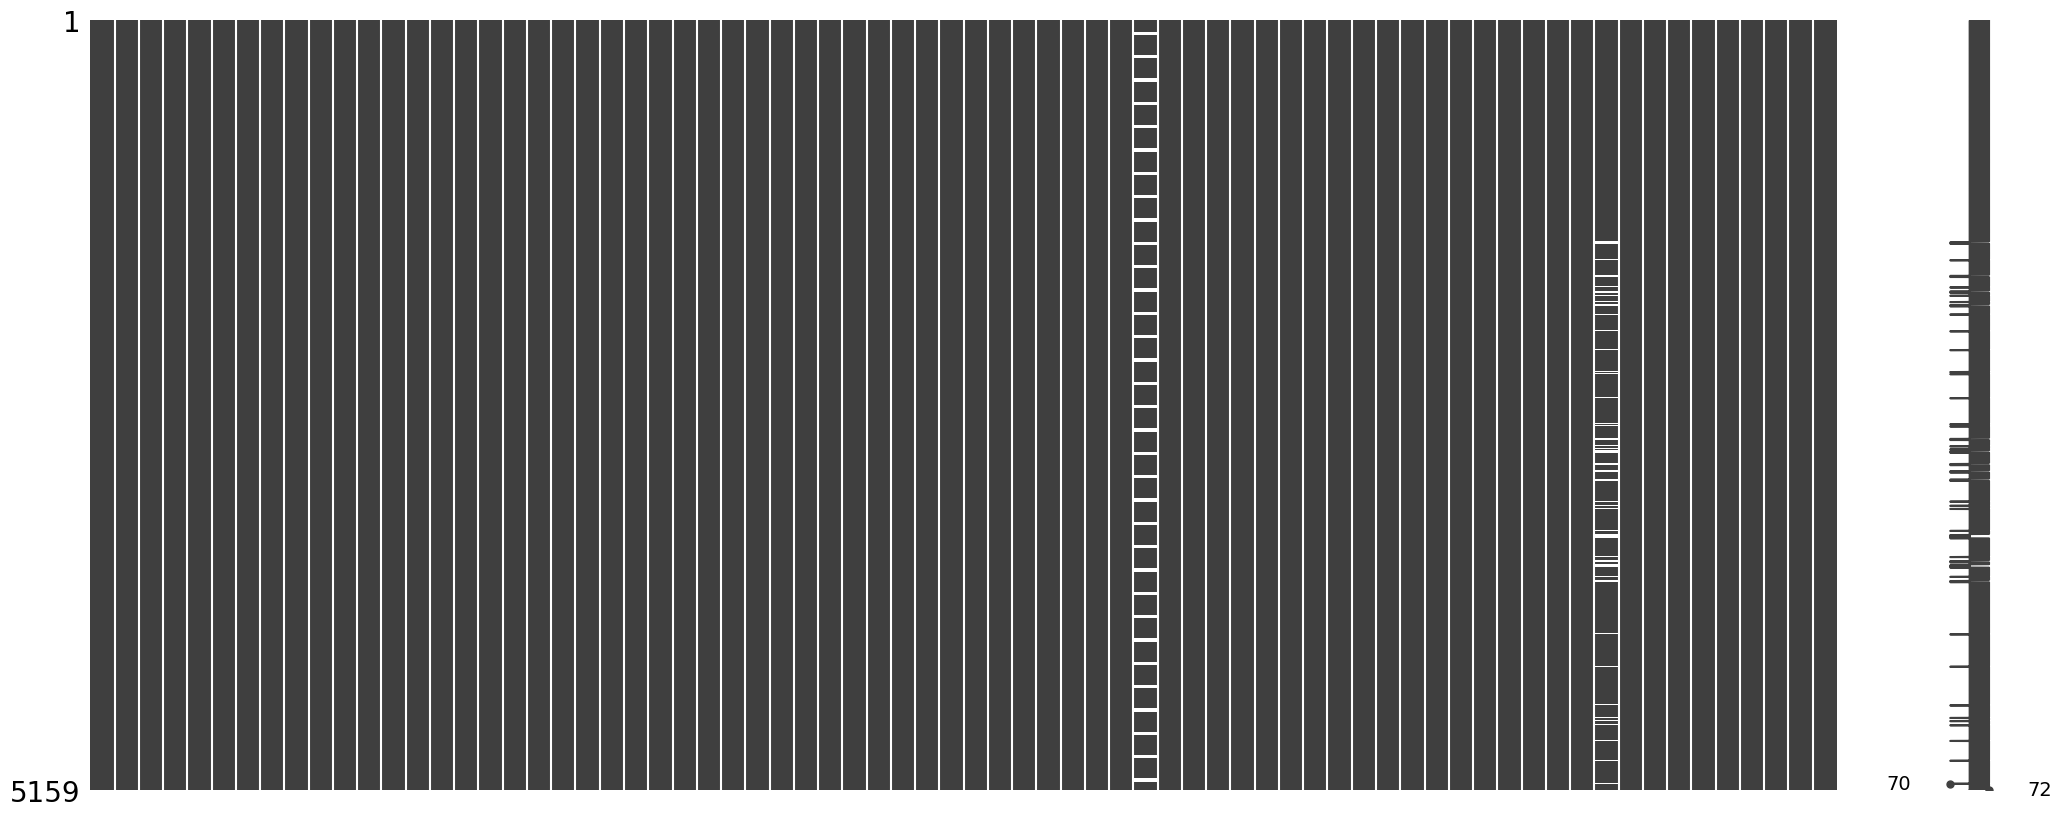

In [72]:
missingno.matrix(merged)

In [73]:
gc.collect()

0

In [74]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'lst_min', 'lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)
imputed_columns = ['lst_min', 'lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

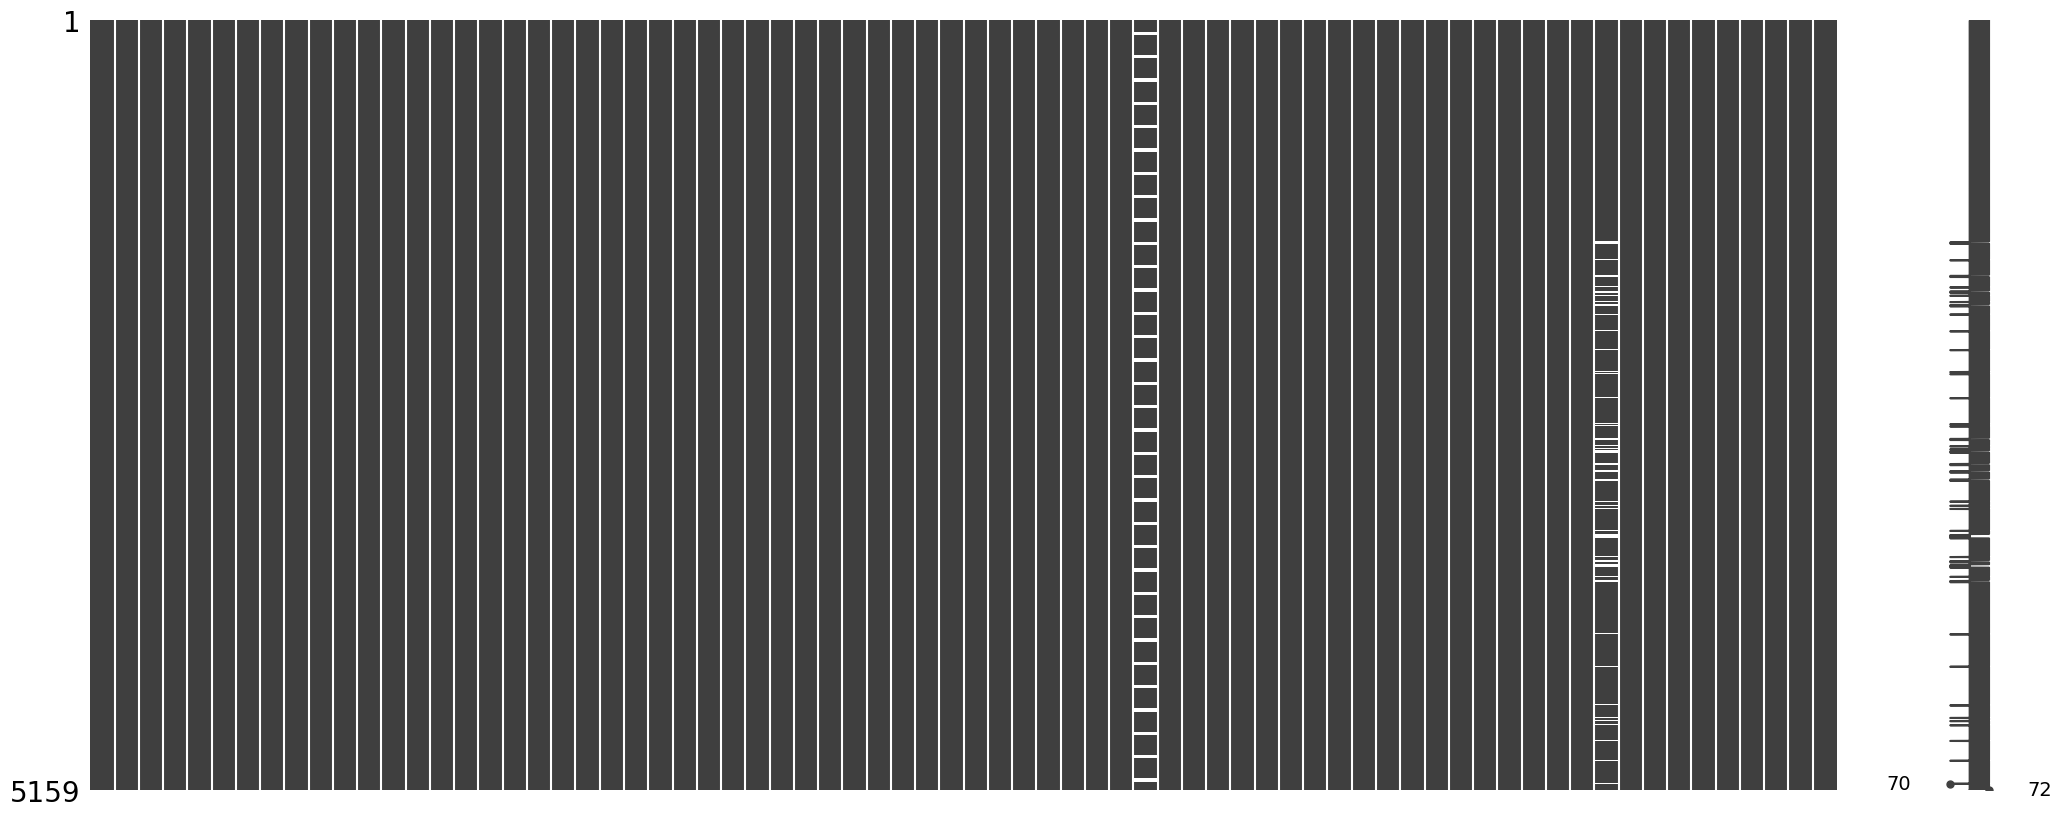

In [75]:
missingno.matrix(merged)

In [76]:
years = merged.year.unique()
years

array([2024])

In [77]:
cell_codes_un = merged.cell_number.unique()
cell_codes_un

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [78]:
rows = []
for year in years:
    for cell in cell_codes_un:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['cell_number'] == cell)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['rainfall_acc'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'cell_number': cell, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [79]:
biovars_df.head(20)

,cell_number,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,0,2024,18.000000,16.571429,44.787645,834.665602,36.000000,-1.000000,37.000000,10.500000,25.833333,25.833333,10.500000,424.000000,206.000000,0.000000,134.844709,386.000000,8.000000,8.000000,386.000000
1,1,2024,18.500000,16.714286,46.428571,765.941686,37.000000,1.000000,36.000000,11.833333,25.666667,25.666667,11.833333,488.000000,286.000000,0.000000,151.449009,459.000000,6.000000,6.000000,459.000000
2,2,2024,18.214286,15.000000,48.387097,718.712473,36.000000,5.000000,31.000000,12.000000,25.000000,25.000000,12.000000,488.000000,286.000000,0.000000,151.449009,459.000000,6.000000,6.000000,459.000000
3,3,2024,17.857143,17.714286,47.876448,817.370931,37.000000,0.000000,37.000000,10.333333,25.500000,25.500000,10.333333,377.000000,168.000000,0.000000,133.945838,351.000000,7.000000,7.000000,351.000000
4,4,2024,18.357143,18.142857,50.396825,819.407451,37.000000,1.000000,36.000000,11.000000,26.166667,26.166667,11.000000,424.000000,206.000000,0.000000,134.844709,386.000000,8.000000,8.000000,386.000000
5,5,2024,18.000000,17.714286,47.876448,851.469318,38.000000,1.000000,37.000000,10.333333,26.000000,26.000000,10.333333,424.000000,206.000000,0.000000,134.844709,386.000000,8.000000,8.000000,386.000000
6,6,2024,17.785714,16.714286,45.173745,810.790326,36.000000,-1.000000,37.000000,10.500000,25.166667,25.166667,10.500000,424.000000,206.000000,0.000000,134.844709,386.000000,8.000000,8.000000,386.000000
7,7,2024,18.714286,16.571429,47.346939,793.125223,38.000000,3.000000,35.000000,11.666667,26.000000,26.000000,11.666667,424.000000,206.000000,0.000000,134.844709,386.000000,8.000000,8.000000,386.000000
8,8,2024,18.428571,16.571429,47.346939,807.479913,37.000000,2.000000,35.000000,11.000000,26.000000,26.000000,11.000000,424.000000,206.000000,0.000000,134.844709,386.000000,8.000000,8.000000,386.000000
9,9,2024,18.357143,17.285714,48.015873,805.561029,38.000000,2.000000,36.000000,11.166667,26.166667,26.166667,11.166667,488.000000,286.000000,0.000000,151.449009,459.000000,6.000000,6.000000,459.000000


In [80]:
merged = pd.merge(merged, biovars_df,  how='left', on=['cell_number', 'year'])

In [81]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2024) & (merged['cell_number'] == 0)]

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,0,2024-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,1,0.453702,0.162273,-0.373644,-0.162273,0.417976,0.173836,-0.328185,-0.173836,0.044335,0.044013,0.054985,0.044013,12.490000,9.364194,10.927097,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,4.883174,10.569020,14.188456,148.323639,151.378399,151.378399,-1.450000,16.550000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0,18.000000,16.571429,44.787645,834.665602,36.000000,-1.000000,37.000000,10.500000,25.833333,25.833333,10.500000,424.000000,206.000000,0.000000,134.844709,386.000000,8.000000,8.000000,386.000000
1,0,2024-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,2,0.459899,0.156819,-0.383792,-0.156819,0.433261,0.163800,-0.360059,-0.163800,0.059659,0.041815,0.063084,0.041815,13.181034,9.434138,11.307586,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,7.137716,114.943450,195.384068,207.398673,358.372156,206.993757,4.910000,15.910000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0,18.000000,16.571429,44.787645,834.665602,36.000000,-1.000000,37.000000,10.500000,25.833333,25.833333,10.500000,424.000000,206.000000,0.000000,134.844709,386.000000,8.000000,8.000000,386.000000
2,0,2024-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,3,0.476548,0.151681,-0.419050,-0.151681,0.461091,0.144800,-0.410378,-0.144800,0.034096,0.020828,0.027412,0.020828,16.062903,9.587419,12.825161,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,0.941541,4.710541,9.336516,13.069732,387.559926,29.187771,5.270000,24.190000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0,18.000000,16.571429,44.787645,834.665602,36.000000,-1.000000,37.000000,10.500000,25.833333,25.833333,10.500000,424.000000,206.000000,0.000000,134.844709,386.000000,8.000000,8.000000,386.000000
3,0,2024-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,4,0.456022,0.120288,-0.422576,-0.120288,0.428696,0.110163,-0.399211,-0.110163,0.042036,0.025916,0.026007,0.025916,21.481333,12.883333,17.182333,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,1.022162,0.302366,28.825284,30.664851,418.224778,30.664851,6.830000,28.130000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0,18.000000,16.571429,44.787645,834.665602,36.000000,-1.000000,37.000000,10.500000,25.833333,25.833333,10.500000,424.000000,206.000000,0.000000,134.844709,386.000000,8.000000,8.000000,386.000000
4,0,2024-05,EL3,αττικη,EL30,αττικη,EL307,"

In [82]:
df_demographics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [83]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1711,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1712,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1713,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1714,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000


In [84]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [85]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1711,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1712,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1713,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1714,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000


In [86]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

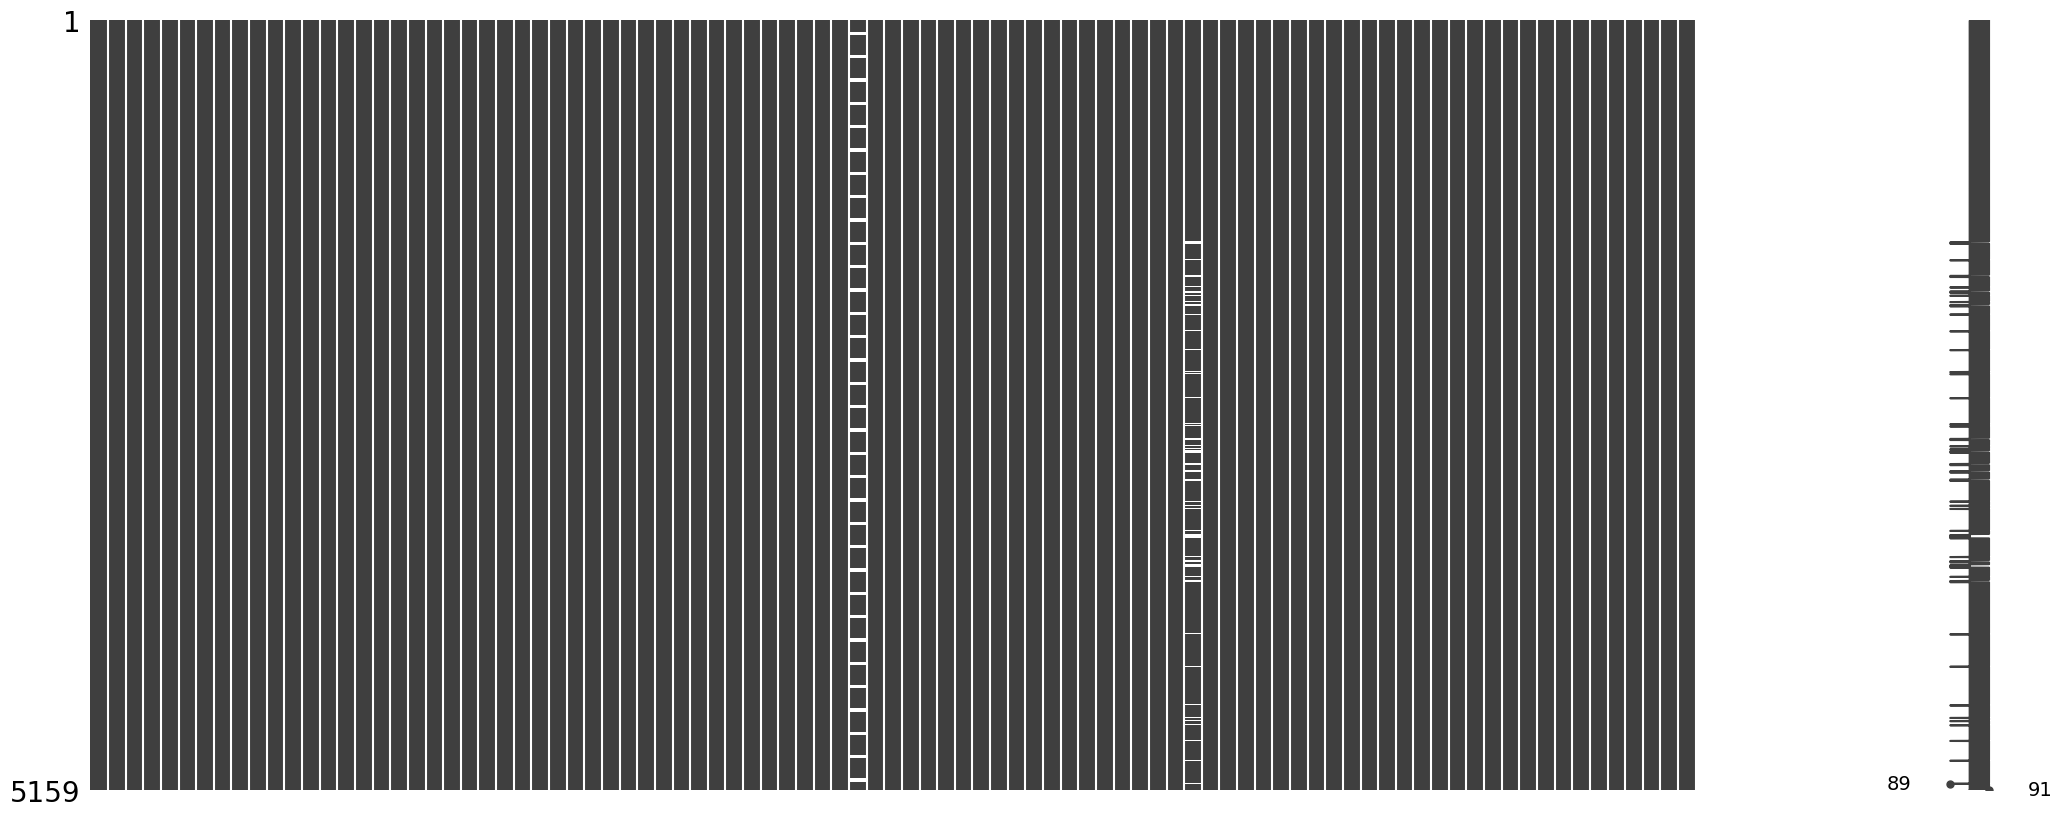

In [87]:
missingno.matrix(dataset)

In [88]:
df_economics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [89]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.340000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1139,EL653,2017,3112.330000
1140,EL653,2018,3111.760000
1141,EL653,2019,3149.580000
1142,EL653,2020,2795.860000


In [90]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [91]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.340000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1139,EL653,2017,3112.330000
1140,EL653,2018,3111.760000
1141,EL653,2019,3149.580000
1142,EL653,2020,2795.860000


In [92]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

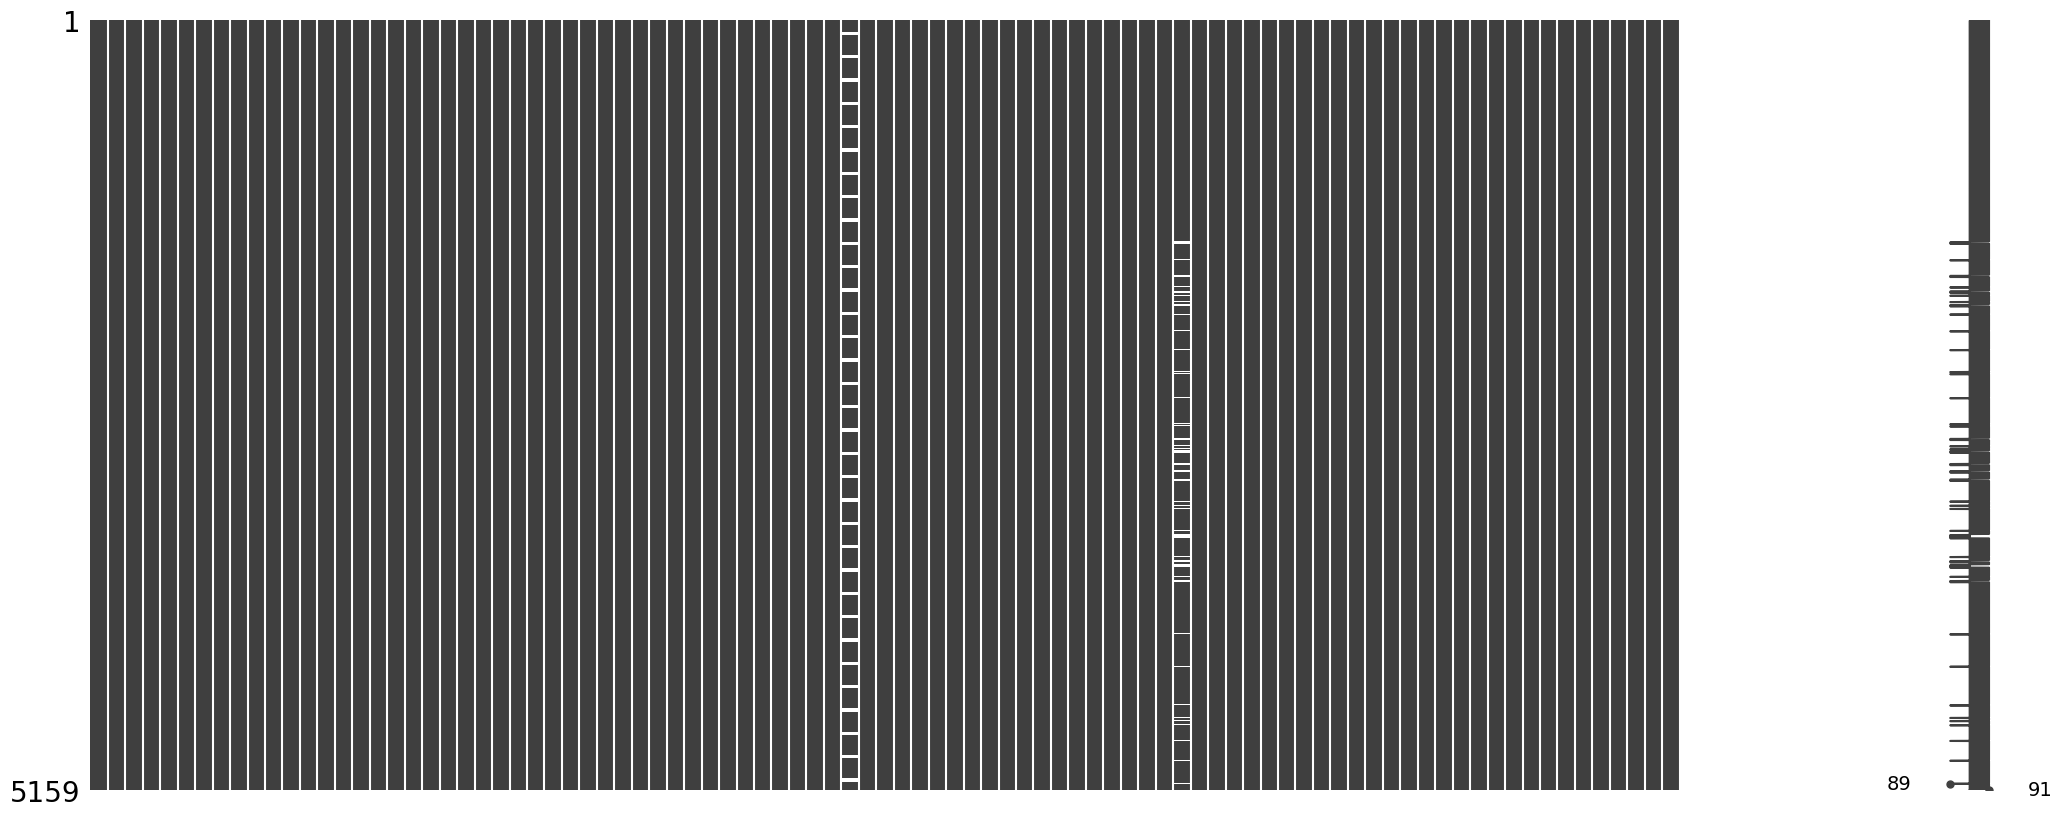

In [93]:
missingno.matrix(dataset)

In [94]:
df_trade = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [95]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
766,EL653,2018,2358.000000,2885.000000
767,EL653,2019,2914.000000,3549.000000
768,EL653,2020,4572.000000,4962.000000
769,EL653,2021,3040.000000,3666.000000


In [96]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [97]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
766,EL653,2018,2358.000000,2885.000000
767,EL653,2019,2914.000000,3549.000000
768,EL653,2020,4572.000000,4962.000000
769,EL653,2021,3040.000000,3666.000000


In [98]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

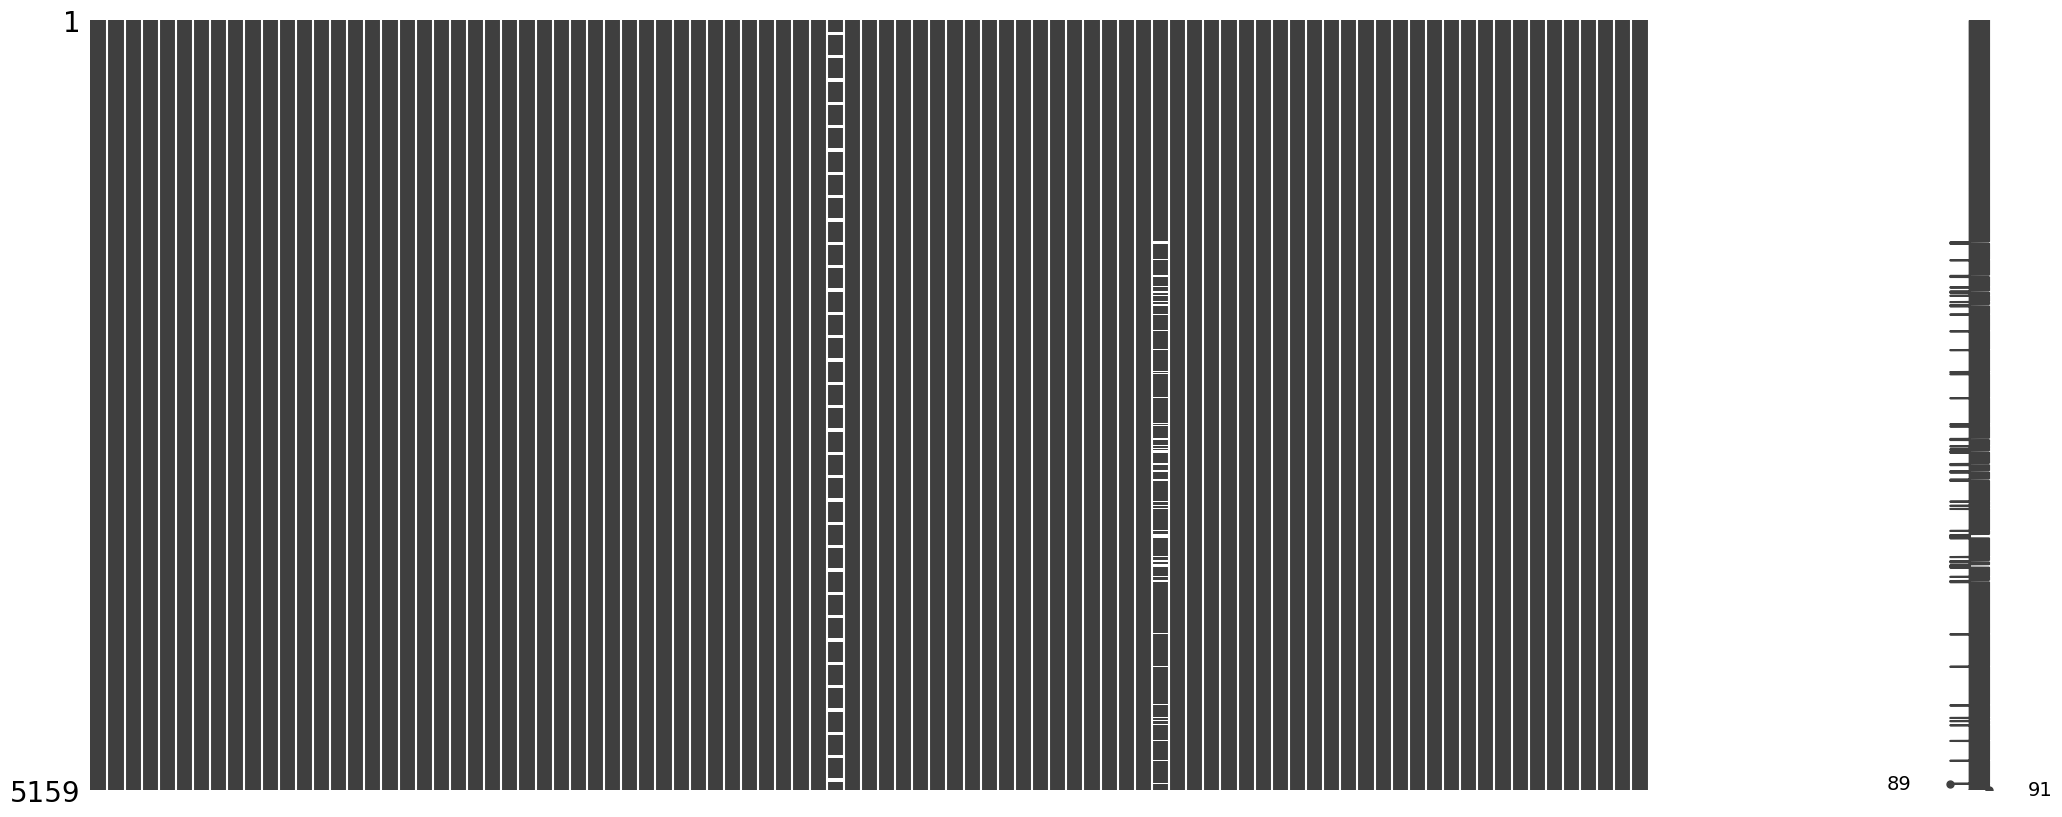

In [99]:
missingno.matrix(dataset)

In [100]:
missing = describe_dataframe(dataset, remove_zeros=True)

In [101]:
missing

,Column,Missing
43,rainfall_mean,14.285700
62,lc_prop2_assessment,7.869700
91,M_Y_LT15,100.000000
92,M_Y15-64,100.000000
93,M_Y_GE65,100.000000
94,M_TOTAL,100.000000
95,F_Y_LT15,100.000000
96,F_Y15-64,100.000000
97,F_Y_GE65,100.000000
98,F_TOTAL,100.000000


In [102]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2024-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,1,0.453702,0.162273,-0.373644,-0.162273,0.417976,0.173836,-0.328185,-0.173836,0.044335,0.044013,0.054985,0.044013,12.490000,9.364194,10.927097,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,4.883174,10.569020,14.188456,148.323639,151.378399,151.378399,-1.450000,16.550000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0,18.000000,16.571429,44.787645,834.665602,36.000000,-1.000000,37.000000,10.500000,25.833333,25.833333,10.500000,424.000000,206.000000,0.000000,134.844709,386.000000,8.000000,8.000000,386.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2024-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,2,0.459899,0.156819,-0.383792,-0.156819,0.433261,0.163800,-0.360059,-0.163800,0.059659,0.041815,0.063084,0.041815,13.181034,9.434138,11.307586,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,7.137716,114.943450,195.384068,207.398673,358.372156,206.993757,4.910000,15.910000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0,18.000000,16.571429,44.787645,834.665602,36.000000,-1.000000,37.000000,10.500000,25.833333,25.833333,10.500000,424.000000,206.000000,0.000000,134.844709,386.000000,8.000000,8.000000,386.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2024-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,3,0.476548,0.151681,-0.419050,-0.151681,0.461091,0.144800,-0.410378,-0.144800,0.034096,0.020828,0.027412,0.020828,16.062903,9.587419,12.825161,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,0.941541,4.710541,9.336516,13.069732,387.559926,29.187771,5.270000,24.190000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0,18.000000,16.571429,44.787645,834.665602,36.000000,-1.000000,37.000000,10.500000,25.833333,25.833333,10.500000,424.000000,206.000000,0.000000,134.844709,386.000000,8.000000,8.000000,386.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,2024-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,4,0.456022,0.120288,-0.422576,-0.120288,0.428696,0.110163,-0.399211,-0.110163,0.042036,0.025916,0.026007,0.025916,21.481333,12.883333,17.182333,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,1.022162,0.302366,28.825284,30.664851,418.224778,30.664851,6.830000,28.130000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0,18.0000

In [103]:
dataset.reset_index(inplace=True, drop=True)

In [104]:
# dataset['cases'].value_counts()

In [105]:
# dataset['cases'].sum()

In [106]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2024-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,1,0.453702,0.162273,-0.373644,-0.162273,0.417976,0.173836,-0.328185,-0.173836,0.044335,0.044013,0.054985,0.044013,12.490000,9.364194,10.927097,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,4.883174,10.569020,14.188456,148.323639,151.378399,151.378399,-1.450000,16.550000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0,18.000000,16.571429,44.787645,834.665602,36.000000,-1.000000,37.000000,10.500000,25.833333,25.833333,10.500000,424.000000,206.000000,0.000000,134.844709,386.000000,8.000000,8.000000,386.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2024-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,2,0.459899,0.156819,-0.383792,-0.156819,0.433261,0.163800,-0.360059,-0.163800,0.059659,0.041815,0.063084,0.041815,13.181034,9.434138,11.307586,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,7.137716,114.943450,195.384068,207.398673,358.372156,206.993757,4.910000,15.910000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0,18.000000,16.571429,44.787645,834.665602,36.000000,-1.000000,37.000000,10.500000,25.833333,25.833333,10.500000,424.000000,206.000000,0.000000,134.844709,386.000000,8.000000,8.000000,386.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2024-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,3,0.476548,0.151681,-0.419050,-0.151681,0.461091,0.144800,-0.410378,-0.144800,0.034096,0.020828,0.027412,0.020828,16.062903,9.587419,12.825161,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,0.941541,4.710541,9.336516,13.069732,387.559926,29.187771,5.270000,24.190000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0,18.000000,16.571429,44.787645,834.665602,36.000000,-1.000000,37.000000,10.500000,25.833333,25.833333,10.500000,424.000000,206.000000,0.000000,134.844709,386.000000,8.000000,8.000000,386.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,2024-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2024,4,0.456022,0.120288,-0.422576,-0.120288,0.428696,0.110163,-0.399211,-0.110163,0.042036,0.025916,0.026007,0.025916,21.481333,12.883333,17.182333,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,1.022162,0.302366,28.825284,30.664851,418.224778,30.664851,6.830000,28.130000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0,18.0000

In [107]:
cols = dataset.columns

In [108]:
print(cols)


Index(['cell_number', 'dt_placement', 'NUTS1_ID', 'NUTS1_NAME', 'NUTS2_ID',
       'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME', 'x',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=102)


In [109]:
len(cols)

102

In [110]:
years = dataset.year.unique().tolist()

In [111]:
for item in years:
    dataset[dataset.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{item}.csv", encoding = enc, index = False)